# 02. 移流・熱・波動 — 拡散と伝播の違い

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 4. Visualization |
| Applied | 5. 熱 〜 7. 波動 |
| Advanced | 11. Advanced Notes |

## 1. Big Picture

時間発展する 1 次元 PDE の三役(順に **移流(伝播)**・**熱(拡散)**・**波動(両方向伝播)**):

$$
\underbrace{\frac{\partial u}{\partial t} + c\frac{\partial u}{\partial x} = 0}_{\text{transport}}
\qquad
\underbrace{\frac{\partial u}{\partial t} = \alpha\frac{\partial^2 u}{\partial x^2}}_{\text{heat}}
\qquad
\underbrace{\frac{\partial^2 u}{\partial t^2} = c^2\frac{\partial^2 u}{\partial x^2}}_{\text{wave}}
$$

一階の空間微分は **流れ**、二階の空間微分は **拡散** を生みます。同じ「場のルール」でも挙動は対照的です。

In [1]:
# Shared setup. Make the book package importable whether or not it is pip-installed,
# then fix the random seed and tidy NumPy printing.
import sys
from pathlib import Path

try:
    import pde_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "pde_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

In [2]:
from pde_book import grids, solvers, plotting, datasets

## 4. 移流方程式 — 形を保って右へ流れる

$\partial_t u + c\,\partial_x u = 0$ の解は $u(x,t) = u_0(x - ct)$、つまり **初期波形がそのまま速度 $c$ で平行移動**。
数値的には風上差分(upwind)で解きます(わずかに数値拡散でなまります)。

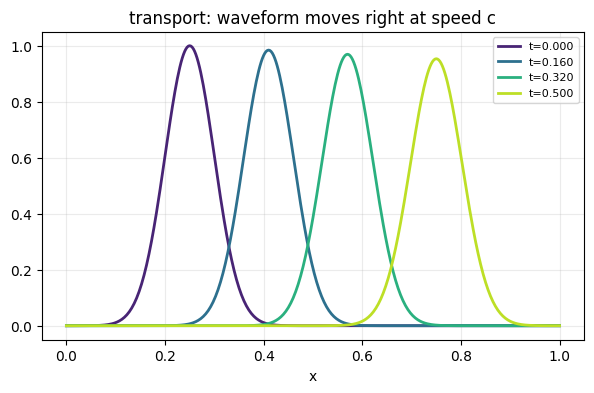

In [3]:
import numpy as np

# Advection: the initial profile translates to the right at speed c.
g = grids.Grid1D(0.0, 1.0, 401)
x, dx = g.x, g.dx
c = 1.0
dt = 0.8 * dx / c                      # CFL = 0.8
steps = 250
u0 = datasets.gaussian(x, 0.25, 0.05)
U = solvers.solve_transport(u0, c, dx, dt, steps, scheme="upwind")
ax = plotting.plot_field_snapshots(x, U, [0, 80, 160, 250], dt=dt,
                                   title="transport: waveform moves right at speed c")
plt.show()

## 5. 熱方程式 — でこぼこをならす

$\partial_t u = \alpha\,\partial_{xx} u$。二階微分(曲がり方)が正(谷)の点は温まり、負(山)の点は冷める。
結果として **鋭い構造は急速に消え、場はなめらかに** なります。段差の初期条件で確認します。

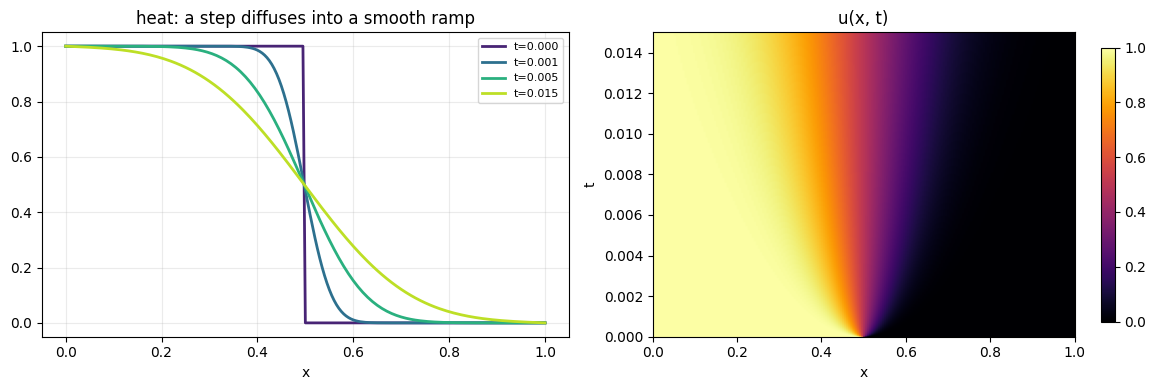

In [4]:
import numpy as np

# Heat: sharp features vanish fast; the field relaxes toward smooth.
g = grids.Grid1D(0.0, 1.0, 201)
x, dx = g.x, g.dx
alpha = 1.0
dt = 0.4 * dx**2 / alpha
steps = 1500
U = solvers.solve_heat_explicit(datasets.step(x, 0.5, 1.0, 0.0), alpha, dx, dt, steps)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
plotting.plot_field_snapshots(x, U, [0, 100, 500, 1500], dt=dt, ax=a1,
                              title="heat: a step diffuses into a smooth ramp")
t = np.arange(U.shape[0]) * dt
plotting.space_time_heatmap(U, x, t, ax=a2, title="u(x, t)")
fig.tight_layout()
plt.show()

### 拡散と伝播の違い

- **熱(拡散)**: 情報は **瞬時に** 全体へにじむ(無限の伝播速度)。エネルギーは散逸し、時間反転できない。
- **移流・波動(伝播)**: 情報は **有限速度** $c$ で運ばれる。形(エネルギー)は保たれ、時間反転できる。

## 7. 波動方程式 — 弦をはじく (Applied)

$\partial_{tt} u = c^2 \partial_{xx} u$。弦の各点の加速度が曲がり方に比例。初期変位を与えて手を離すと、
波が **左右に分かれて伝播** し、端で反射します。両端固定(Dirichlet)の弦をはじきます。

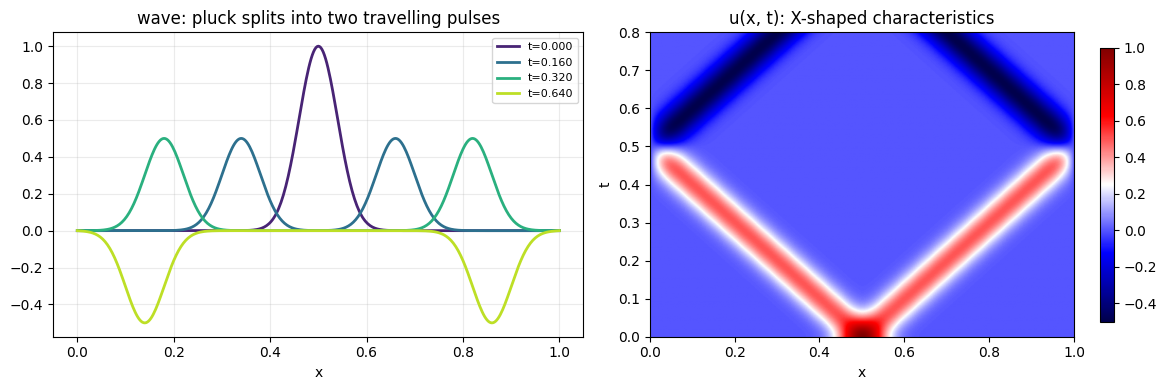

In [5]:
import numpy as np

# Wave: a plucked string splits into left/right travelling waves and reflects.
g = grids.Grid1D(0.0, 1.0, 401)
x, dx = g.x, g.dx
c = 1.0
dt = 0.8 * dx / c
steps = 400
u0 = datasets.gaussian(x, 0.5, 0.04)   # initial pluck
v0 = np.zeros_like(x)
U = solvers.solve_wave(u0, v0, c, dx, dt, steps)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
plotting.plot_field_snapshots(x, U, [0, 80, 160, 320], dt=dt, ax=a1,
                              title="wave: pluck splits into two travelling pulses")
t = np.arange(U.shape[0]) * dt
plotting.space_time_heatmap(U, x, t, ax=a2, cmap="seismic", title="u(x, t): X-shaped characteristics")
fig.tight_layout()
plt.show()

時空間ヒートマップの **X 字** は、波が速度 $\pm c$ の **特性線** $x \pm ct = \text{const}$ に沿って伝わることを示します。

## Exercises

1. 移流方程式で $c<0$(左へ流れる)場合に upwind の風上側が変わることを確認し、解いてみよ。
2. 熱方程式で初期条件をガウス分布にすると、解が「広がるガウス分布」になることを数値で確かめよ。
3. 波動方程式で初期速度 $v_0 \ne 0$(たたく)場合と初期変位(はじく)場合の違いを比べよ。

## Advanced Notes

- **d'Alembert の公式**: 1 次元波動の一般解は $u(x,t) = \tfrac12[u_0(x-ct)+u_0(x+ct)] + \tfrac{1}{2c}\int_{x-ct}^{x+ct} v_0$。
- **熱核**: 熱方程式の基本解は正規分布 $\frac{1}{\sqrt{4\pi\alpha t}}e^{-x^2/4\alpha t}$。畳み込みで一般の初期条件の解が書ける。
- **数値拡散**: upwind は一次精度で、移流を解くと余分な拡散(波形のなまり)が入る。高次スキーム(Lax-Wendroff 等)で軽減できる(06 章)。